In [14]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
import zipfile

zip_path = "/content/Plant_Disease_Workshop.zip"

extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [16]:
dataset_path="/content/Plant_Disease_Workshop"
print(os.listdir(dataset_path))

['val', 'train']


In [17]:
train_path="/content/Plant_Disease_Workshop/train"
print(os.listdir(dataset_path))

['val', 'train']


In [18]:
val_path="/content/Plant_Disease_Workshop/val"
print(os.listdir(dataset_path))

['val', 'train']


In [19]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"
print("======== TRSIN DATA ======== \n")

for folder in os.listdir(train_path):
  folder_path = os.path.join(train_path, folder)
  print(folder, ":", len(os.listdir(folder_path)), "images")

print("======== VALIDATION DATA ======== \n")

for folder in os.listdir(val_path):
  folder_path = os.path.join(val_path, folder)
  print(folder, ":", len(os.listdir(folder_path)), "images")

======== TRSIN DATA ======== 

Potato___Early_blight : 800 images
Potato___Late_blight : 800 images
Potato___healthy : 121 images
======== VALIDATION DATA ======== 

Potato___Early_blight : 200 images
Potato___Late_blight : 200 images
Potato___healthy : 31 images


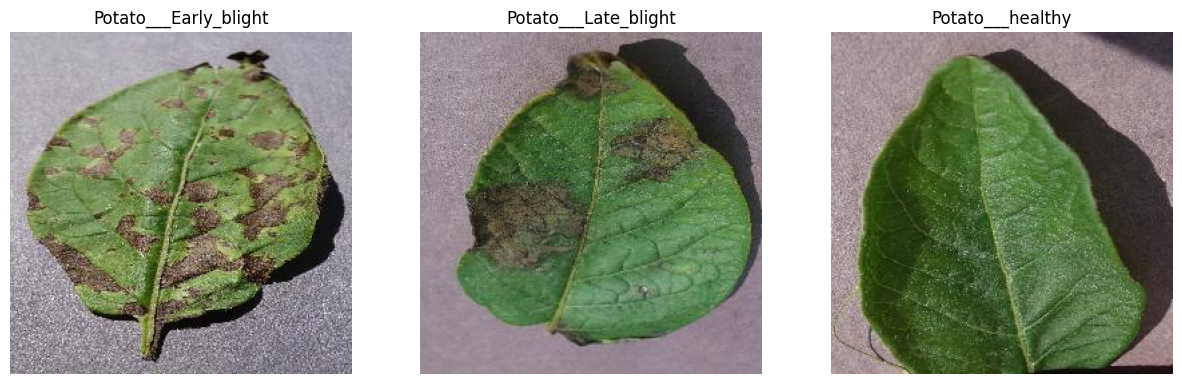

In [20]:
plt.figure(figsize=(15,5))
classes = os.listdir(train_path)
for i, folder in enumerate(classes):
  image_name = os.listdir(os.path.join(train_path,folder))[0]
  image_path = os.path.join(train_path,folder,image_name)
  image = cv2.imread(image_path)
  image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  plt.subplot(1,3,i+1)
  plt.imshow(image)
  plt.title(folder)
  plt.axis("off")
plt.show()

In [21]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"
image_size = (64,64)

In [22]:
X_train = []
y_train = []

X_val = []
y_val = []

In [23]:
for label in os.listdir(train_path):
  folder_path = os.path.join(train_path,label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path,image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image,image_size)
    X_train.append(image)
    y_train.append(label)
print("Training Images loaded successfully")

Training Images loaded successfully


In [24]:
for label in os.listdir(val_path):
  folder_path = os.path.join(val_path,label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path,image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image,image_size)
    X_val.append(image)
    y_val.append(label)
print("Validation Images loaded successfully")

Validation Images loaded successfully


In [25]:
print("Traing images:", len(X_train))
print("Training labels:", len(y_train))
print()
print("validation images:",len(X_val))
print("validation labels:",len(y_val))

Traing images: 1721
Training labels: 1721

validation images: 431
validation labels: 431


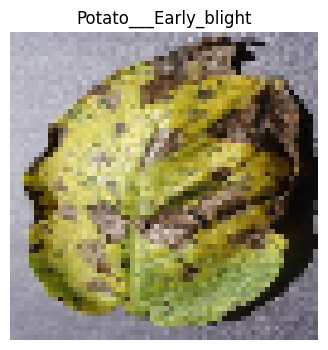

In [26]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_train[5],cv2.COLOR_BGR2RGB))
plt.title(y_train[5])
plt.axis("off")
plt.show()

In [27]:
X_train = np.array(X_train)
X_val = np.array(X_val)

y_train = np.array(y_train)
y_val = np.array(y_val)

print("Converted successfully!")

Converted successfully!


In [28]:
X_train.shape

(1721, 64, 64, 3)

In [29]:
X_val.shape

(431, 64, 64, 3)

In [30]:
X_train = X_train.reshape(X_train.shape[0],-1)
X_val = X_val.reshape(X_val.shape[0],-1)

print("Images flattened Successfully!!")

Images flattened Successfully!!


In [31]:
X_train.shape

(1721, 12288)

In [32]:
X_val.shape

(431, 12288)

In [33]:
X_train = X_train / 255.0
X_val = X_val / 255.0

print(" ** N o r m a l i z a t i o n - c o m p l e t e d ! ! **")

 ** N o r m a l i z a t i o n - c o m p l e t e d ! ! **


In [34]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.fit_transform(y_val)

print("labels encoded successfully!")

labels encoded successfully!


In [35]:
print("Encoded classes : ")
print(encoder.classes_)

print()

print("First 10 labels : ")
print(  y_train[:10])

Encoded classes : 
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

First 10 labels : 
[0 0 0 0 0 0 0 0 0 0]


In [36]:
X_train.shape

(1721, 12288)

In [37]:
X_val.shape

(431, 12288)

In [38]:
print("training features shape:",X_train.shape)
print("training labels shape:",y_train.shape)
print()
print("validation features shape:",X_val.shape)
print("validation labels shape:",y_val.shape)


training features shape: (1721, 12288)
training labels shape: (1721,)

validation features shape: (431, 12288)
validation labels shape: (431,)


In [39]:
logistic_model = LogisticRegression(max_iter=1000)
print("logistic regression moddel created successfully")


logistic regression moddel created successfully


In [40]:
logistic_model.fit(X_train,y_train)
print("Model training is completed")

Model training is completed


In [41]:
y_pred = logistic_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [42]:
print("Actual labels:",y_val[:10])
print("Predicted labels:",y_pred[:10])

Actual labels: [0 0 0 0 0 0 0 0 0 0]
Predicted labels: [0 0 0 0 0 0 0 0 0 0]


In [43]:
y_pred = logistic_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [44]:
accuracy = accuracy_score(y_val,y_pred)
print("Accuracy:",round(accuracy*100,2),"%")

Accuracy: 90.72 %


In [45]:
y_pred = logistic_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [46]:
cmx = confusion_matrix(y_val,y_pred)
print("Confusion matrix is:\n",cmx)

Confusion matrix is:
 [[185  15   0]
 [  8 189   3]
 [  0  14  17]]


In [47]:
print(classification_report(y_val,y_pred,target_names=encoder.classes_))

                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.93      0.94       200
 Potato___Late_blight       0.87      0.94      0.90       200
     Potato___healthy       0.85      0.55      0.67        31

             accuracy                           0.91       431
            macro avg       0.89      0.81      0.84       431
         weighted avg       0.91      0.91      0.90       431



In [48]:
predicted_labels = encoder.inverse_transform(y_pred[:10])

print("First 10 Predicted Disease Names:")
print(predicted_labels)

First 10 Predicted Disease Names:
['Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight']


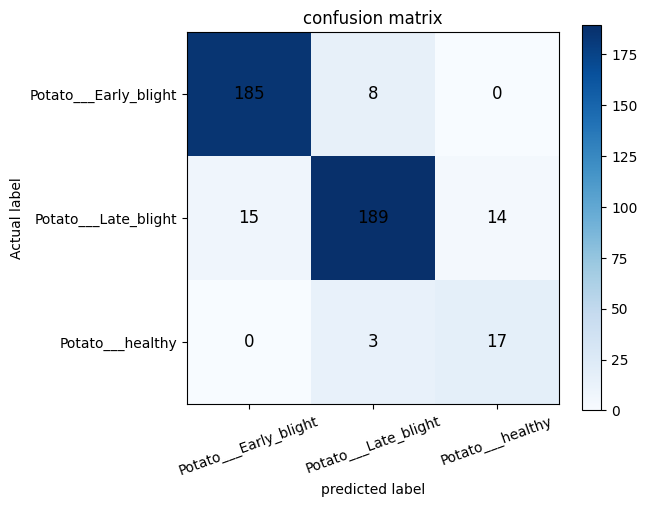

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cmx,cmap="Blues")
plt.title("confusion matrix")
plt.colorbar()

plt.xticks(range(3),encoder.classes_,rotation=20)
plt.yticks(range(3),encoder.classes_)

for i in range(len(cmx)):
  for j in range(len(cmx[i])):
    plt.text(j, i, cmx[j][i],
             ha="center",
             va="center",
             fontsize=12)
plt.xlabel("predicted label")
plt.ylabel("Actual label")
plt.show()

In [50]:
print("="*40)
print("Logistic Regression Completed Successfully")
print("="*40)

print(f"Accuracy:{accuracy*100:.2f}%")

Logistic Regression Completed Successfully
Accuracy:90.72%


In [51]:
svm_model = SVC(kernel="linear")
print("SVM model created successfully")



SVM model created successfully


In [52]:
svm_fit=svm_model.fit(X_train,y_train)
print("Model training is completed")

Model training is completed


In [53]:
y_pred = svm_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [54]:
svmacc = accuracy_score(y_val, y_pred)
print(f"Accuracy for SVM: {accuracy * 100:.2f}%")

Accuracy for SVM: 90.72%


In [55]:
cm = confusion_matrix(y_val, y_pred)
print("Confusion matrix is:\n", cm)

Confusion matrix is:
 [[183  17   0]
 [  9 188   3]
 [  1   8  22]]


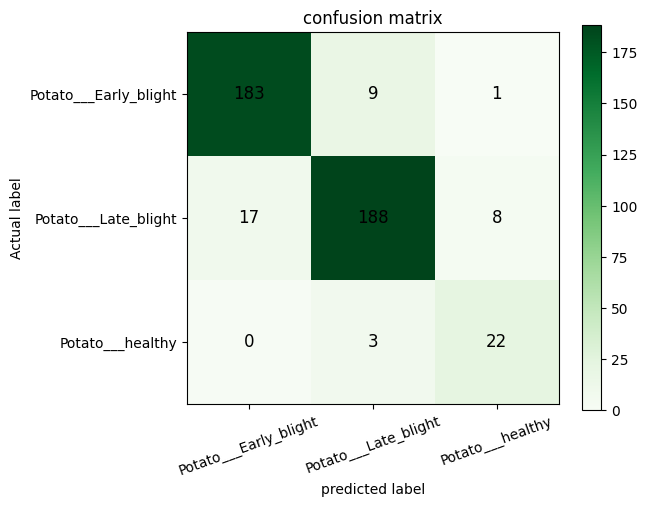

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm,cmap="Greens")
plt.title("confusion matrix")
plt.colorbar()

plt.xticks(range(3),encoder.classes_,rotation=20)
plt.yticks(range(3),encoder.classes_)

for i in range(len(cm)):
  for j in range(len(cm[i])):
    plt.text(j, i, cm[j][i],
             ha="center",
             va="center",
             fontsize=12)
plt.xlabel("predicted label")
plt.ylabel("Actual label")
plt.show()

In [57]:
print("="*40)
print("SVM Completed Successfully")
print("="*40)

print(f"Accuracy:{svmacc*100:.2f}%")

SVM Completed Successfully
Accuracy:91.18%


In [58]:
from google.colab import files
uploaded = files.upload()

Saving images (1).jpg to images (1).jpg


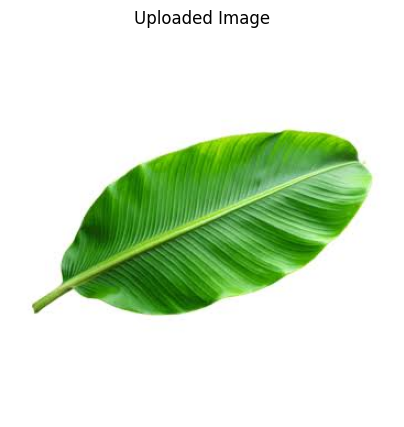

In [59]:
image_name = list(uploaded.keys())[0]
image = cv2.imread(image_name)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

In [60]:
test_image = cv2.resize(image,(64,64))
test_image = test_image.reshape(1,-1)
test_image = test_image / 255.0
print("Image processed successfully!")

Image processed successfully!


In [61]:
prediction = svm_model.predict(test_image)
predicted_disease = encoder.inverse_transform(prediction)
print("Predicted Disease:",predicted_disease[0])

Predicted Disease: Potato___healthy


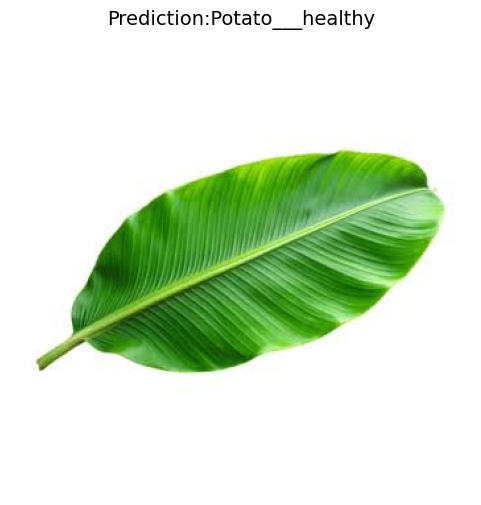

In [62]:
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Prediction:" + predicted_disease[0],fontsize=14)
plt.axis("off")
plt.show()


In [63]:
if predicted_disease[0] == 'Potato___Early_blight':
  print("Early Blight")
  print("advice : remove inflected leaves and apply a suitable")
elif predicted_disease[0] == 'Potato___Late_blight':
  print("Late Blight")
  print("Advice : improve drainage , and overhead watering")
elif predicted_disease[0] == 'Potato___healthy':
  print("Healthy")
  print("advice : no disease detected. continue regular crop care.")

Healthy
advice : no disease detected. continue regular crop care.


In [64]:
comparison = {
    "Model":["Logistic Regression","Support Vector Machine"],
    "Accuracy":[accuracy*100,svmacc*100]
}
import pandas as pd
comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Accuracy
0,Logistic Regression,90.719258
1,Support Vector Machine,91.183295


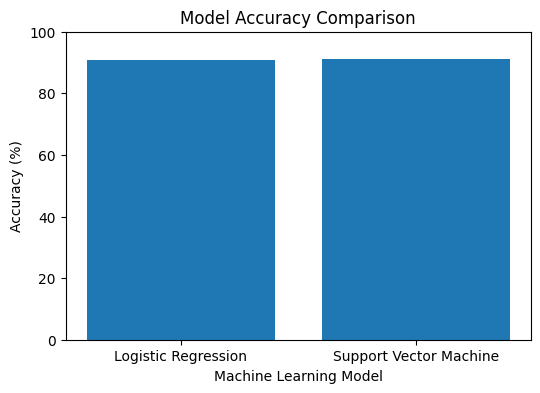

In [65]:
plt.figure(figsize=(6,4))
plt.bar(comparison_df["Model"],comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
plt.show()

In [66]:
if svmacc > accuracy:
  print("Best Model : Support Vector Machine (SVM)")
else:
  print("Best Model : Logistic Regression")

Best Model : Support Vector Machine (SVM)
